In [24]:
import numpy as np


def make_grid() -> np.ndarray:
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
            np.arange(y_min, y_max, 0.1))
  return np.c_[xx.ravel(), yy.ravel()]

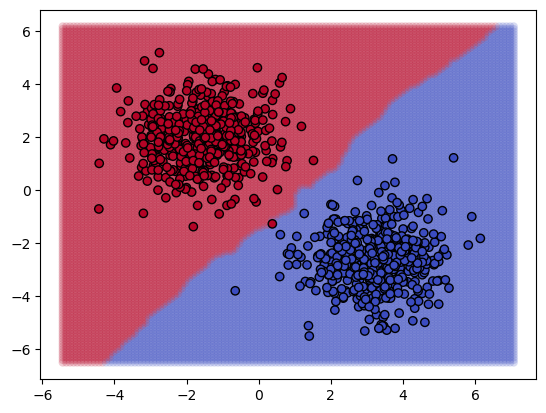

In [29]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

N_SAMPLES = 1000

X, y = make_blobs(n_samples=N_SAMPLES, centers=2)

knn = KNeighborsClassifier()

knn.fit(X, y)

grid = make_grid()

y_pred = knn.predict(grid)

plt.figure()
plt.scatter(grid[:, 0], grid[:, 1], c=y_pred, alpha=0.2, cmap='coolwarm', edgecolor='none')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
plt.show()

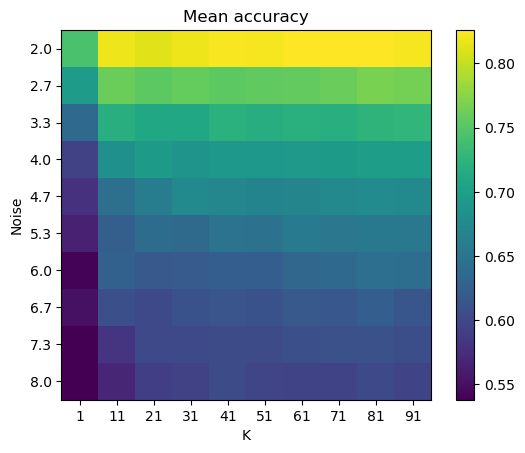

In [28]:
ks = range(1, N_SAMPLES // 10, N_SAMPLES // 100)
noises = np.linspace(start=2, stop=8, num=10)

mean_accuracies = []

for noise in noises:

  X, y = make_blobs(n_samples=N_SAMPLES, centers=2, cluster_std=noise, random_state=0)
  kf = KFold(n_splits=10, shuffle=True, random_state=0)

  for k in ks:

    accuracies = []

    for train_index, test_index in kf.split(X):

      knn = KNeighborsClassifier(n_neighbors=k)
      knn.fit(X[train_index], y[train_index])

      y_pred = knn.predict(X[test_index])
      
      accuracies.append(accuracy_score(y[test_index], y_pred))

    mean_accuracies.append(np.mean(accuracies))

mean_accuracies = np.array(mean_accuracies).reshape(len(noises), len(ks))

plt.imshow(mean_accuracies, interpolation='nearest')
plt.colorbar()
plt.xlabel('K')
plt.ylabel('Noise')
plt.xticks(np.arange(len(ks)), ks)
plt.yticks(np.arange(len(noises)), [f'{n:.1f}' for n in noises])
plt.title('Mean accuracy')
plt.show()